# SAM3 OpenVINO — Variant Comparison

This notebook compares **SAM3 OpenVINO** model variants (**FP16**, **INT8**, **INT4**) side-by-side across three prompt modes:

- **Text prompt** — detect objects by category name
- **Box prompt** — segment a specific bounding box region
- **Visual exemplar** — fit on a reference image, predict on new images

For each prompt mode, we measure:
- **Quality** — mask IoU between FP16 (baseline) and quantized variants
- **Latency** — mean inference time per variant
- **Detection count** — number of objects found


In [16]:
# Copyright (C) 2025-2026 Intel Corporation
# SPDX-License-Identifier: Apache-2.0

from __future__ import annotations

import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch

from instantlearn.data import Sample
from instantlearn.models import SAM3OpenVINO
from instantlearn.models.sam3 import SAM3OVVariant, Sam3PromptMode

# Image paths (relative to library/ directory)
COCO_DIR = Path("assets/coco/")
IMG1 = COCO_DIR / "000000267704.jpg"  
IMG2 = COCO_DIR / "000000286874.jpg"  
IMG3 = COCO_DIR / "000000390341.jpg" 


# Variants to compare
VARIANTS = {
    "FP16": SAM3OVVariant.FP16,
    "INT8": SAM3OVVariant.INT8,
    "INT4": SAM3OVVariant.INT4,
}

# If you have an Intel GPU, you can set DEVICE = "GPU"  
DEVICE = "CPU"

def measure_latency(model: SAM3OpenVINO, target, n: int = 5) -> float:
    """Run predict() n times and return mean latency in ms."""
    times = []
    for _ in range(n):
        t0 = time.perf_counter()
        model.predict(target)
        times.append((time.perf_counter() - t0) * 1000)
    return float(np.mean(times))


def compute_mask_iou(mask_a: torch.Tensor, mask_b: torch.Tensor) -> float:
    """Compute IoU between two binary mask tensors of the same shape."""
    a = mask_a.bool().flatten()
    b = mask_b.bool().flatten()
    intersection = (a & b).sum().item()
    union = (a | b).sum().item()
    return intersection / union if union > 0 else 0.0


def overlay_masks(image_path, masks: torch.Tensor, alpha: float = 0.5) -> np.ndarray:
    """Overlay colored masks on an image."""
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    overlay = img.copy()
    colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0), (255, 0, 255)]
    for i, mask in enumerate(masks):
        color = colors[i % len(colors)]
        binary = mask.numpy().astype(bool)
        overlay[binary] = (
            np.array(color) * alpha + overlay[binary] * (1 - alpha)
        ).astype(np.uint8)
    return overlay


print("Setup complete. Using device:", DEVICE)

Setup complete. Using device: CPU


## 1. Load Models

Load all three model variants. Each auto-downloads from HuggingFace on first use.

In [17]:
models = {}
for name, variant in VARIANTS.items():
    print(f"Loading {name} ({variant.value})...")
    models[name] = SAM3OpenVINO(variant=variant, device=DEVICE)
    print(f"  Loaded from: {models[name].model_dir}")

print(f"\nLoaded {len(models)} variants: {list(models.keys())}")

Loading FP16 (openvino-fp16)...


Fetching 18 files: 100%|██████████| 18/18 [00:00<00:00, 60591.87it/s]


  Loaded from: /home/devuser/.cache/huggingface/hub/models--rajeshgangireddy--exported_sam3/snapshots/df86be5fa6f8743525849708b0f49e27414576ff/openvino-fp16
Loading INT8 (openvino-nncf-int8)...


Fetching 18 files: 100%|██████████| 18/18 [00:00<00:00, 69775.85it/s]


  Loaded from: /home/devuser/.cache/huggingface/hub/models--rajeshgangireddy--exported_sam3/snapshots/df86be5fa6f8743525849708b0f49e27414576ff/openvino-nncf-int8
Loading INT4 (openvino-nncf-int4)...


Fetching 18 files: 100%|██████████| 18/18 [00:00<00:00, 137518.16it/s]


  Loaded from: /home/devuser/.cache/huggingface/hub/models--rajeshgangireddy--exported_sam3/snapshots/df86be5fa6f8743525849708b0f49e27414576ff/openvino-nncf-int4

Loaded 3 variants: ['FP16', 'INT8', 'INT4']


## 2. Text Prompt Comparison

Detect "elephant" on the same image using each variant. Compare mask overlays, detection counts, and latency.

FP16: 7 detections, 5867.8 ms
INT8: 7 detections, 4572.3 ms
INT4: 6 detections, 4576.3 ms


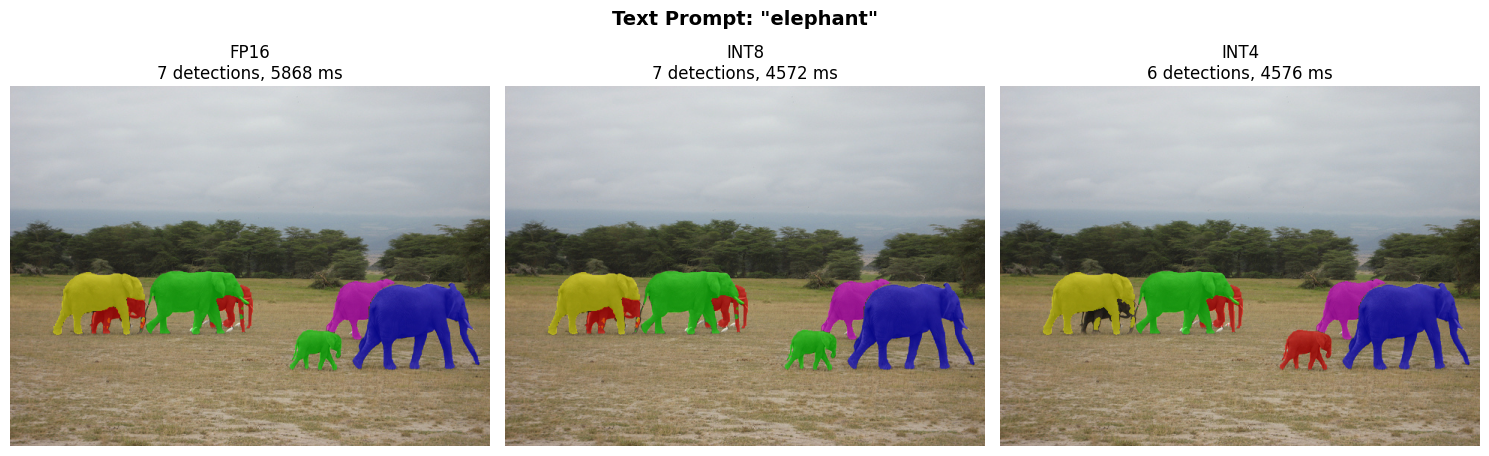

In [18]:
target = Sample(image_path=str(IMG1), categories=["elephant"], category_ids=[0])

text_results = {}
text_latencies = {}
for name, model in models.items():
    # single prediction
    pred = model.predict(target)
    # Measure
    latency = measure_latency(model, target, n=5)
    text_results[name] = pred[0]
    text_latencies[name] = latency
    n_det = len(pred[0]["pred_masks"])
    print(f"{name}: {n_det} detections, {latency:.1f} ms") 

# Visualization
fig, axes = plt.subplots(1, len(VARIANTS), figsize=(5 * len(VARIANTS), 5))
for ax, (name, pred) in zip(axes, text_results.items()):
    vis = overlay_masks(IMG1, pred["pred_masks"])
    ax.imshow(vis)
    ax.set_title(f"{name}\n{len(pred['pred_masks'])} detections, {text_latencies[name]:.0f} ms")
    ax.axis("off")
fig.suptitle('Text Prompt: "elephant"', fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Box Prompt Comparison

Segment a specific elephant ROI using a bounding box prompt. Compare mask IoU between FP16 (baseline) and quantized variants.

FP16: 1 detections, 5820.7 ms
INT8: 1 detections, 4574.5 ms
INT4: 1 detections, 4699.6 ms

Mask IoU vs FP16 baseline:
  INT8: IoU = 0.9957
  INT4: IoU = 0.9783


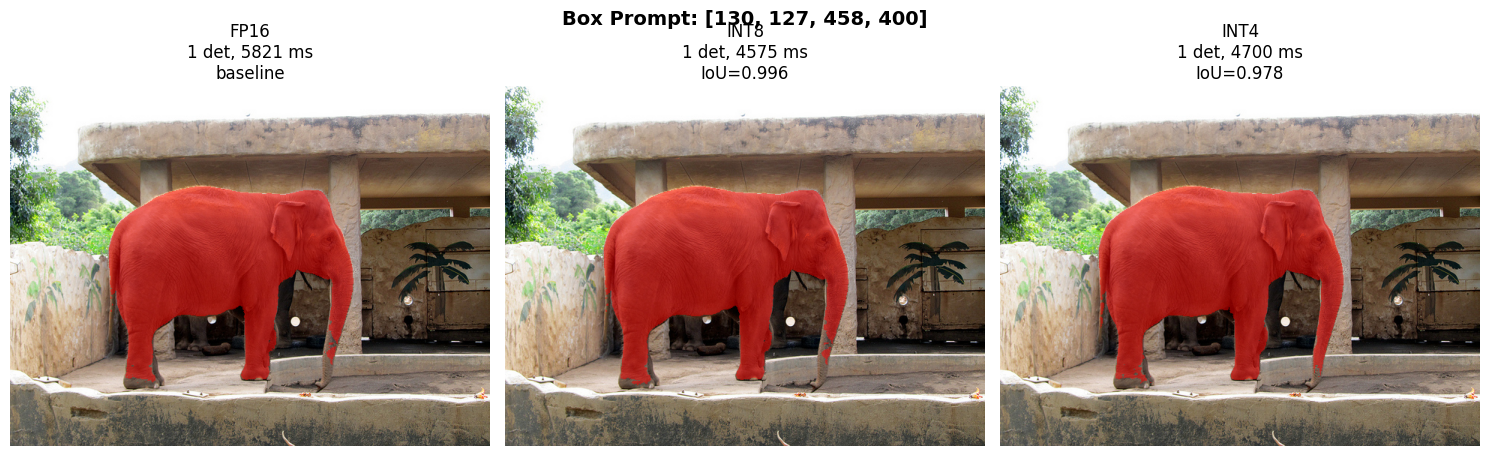

In [19]:
IMG2_BOX_COORDS = [130, 127, 458, 400]  # [x1, y1, x2, y2]
box_target = Sample(
    image_path=str(IMG2),
    bboxes=np.array([IMG2_BOX_COORDS]),
    categories=["elephant"],
    category_ids=[0],
)

box_results = {}
box_latencies = {}
for name, model in models.items():
    pred = model.predict(box_target) 
    latency = measure_latency(model, box_target, n=5)  
    box_results[name] = pred[0]
    box_latencies[name] = latency
    print(f"{name}: {len(pred[0]['pred_masks'])} detections, {latency:.1f} ms")

# IoU vs FP16 baseline
baseline_masks = box_results["FP16"]["pred_masks"]
print("\nMask IoU vs FP16 baseline:")
box_ious = {}
for name, pred in box_results.items():
    if name == "FP16":
        box_ious[name] = 1.0
        continue
    # Compare union of all masks between variants
    if len(baseline_masks) > 0 and len(pred["pred_masks"]) > 0:
        base_union = baseline_masks.sum(dim=0).clamp(max=1)
        pred_union = pred["pred_masks"].sum(dim=0).clamp(max=1)
        iou = compute_mask_iou(base_union, pred_union)
    else:
        iou = 0.0
    box_ious[name] = iou
    print(f"  {name}: IoU = {iou:.4f}")

# Visualization
fig, axes = plt.subplots(1, len(VARIANTS), figsize=(5 * len(VARIANTS), 5))
for ax, (name, pred) in zip(axes, box_results.items()):
    vis = overlay_masks(IMG2, pred["pred_masks"])
    ax.imshow(vis)
    iou_str = f"IoU={box_ious[name]:.3f}" if name != "FP16" else "baseline"
    ax.set_title(f"{name}\n{len(pred['pred_masks'])} det, {box_latencies[name]:.0f} ms\n{iou_str}")
    ax.axis("off")
fig.suptitle(f"Box Prompt: {IMG2_BOX_COORDS}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Visual Exemplar Comparison

Fit on a reference image with a bounding box, predict on a different image. This tests cross-image transfer quality across variants.

Loading FP16 in VISUAL_EXEMPLAR mode...


Fetching 18 files: 100%|██████████| 18/18 [00:00<00:00, 62291.64it/s]


  FP16: 13 detections, 5851.7 ms
Loading INT8 in VISUAL_EXEMPLAR mode...


Fetching 18 files: 100%|██████████| 18/18 [00:00<00:00, 66930.38it/s]


  INT8: 13 detections, 4588.5 ms
Loading INT4 in VISUAL_EXEMPLAR mode...


Fetching 18 files: 100%|██████████| 18/18 [00:00<00:00, 69647.11it/s]


  INT4: 8 detections, 4603.6 ms

Mask IoU vs FP16 baseline (visual exemplar):
  INT8: IoU = 0.9987
  INT4: IoU = 0.8249


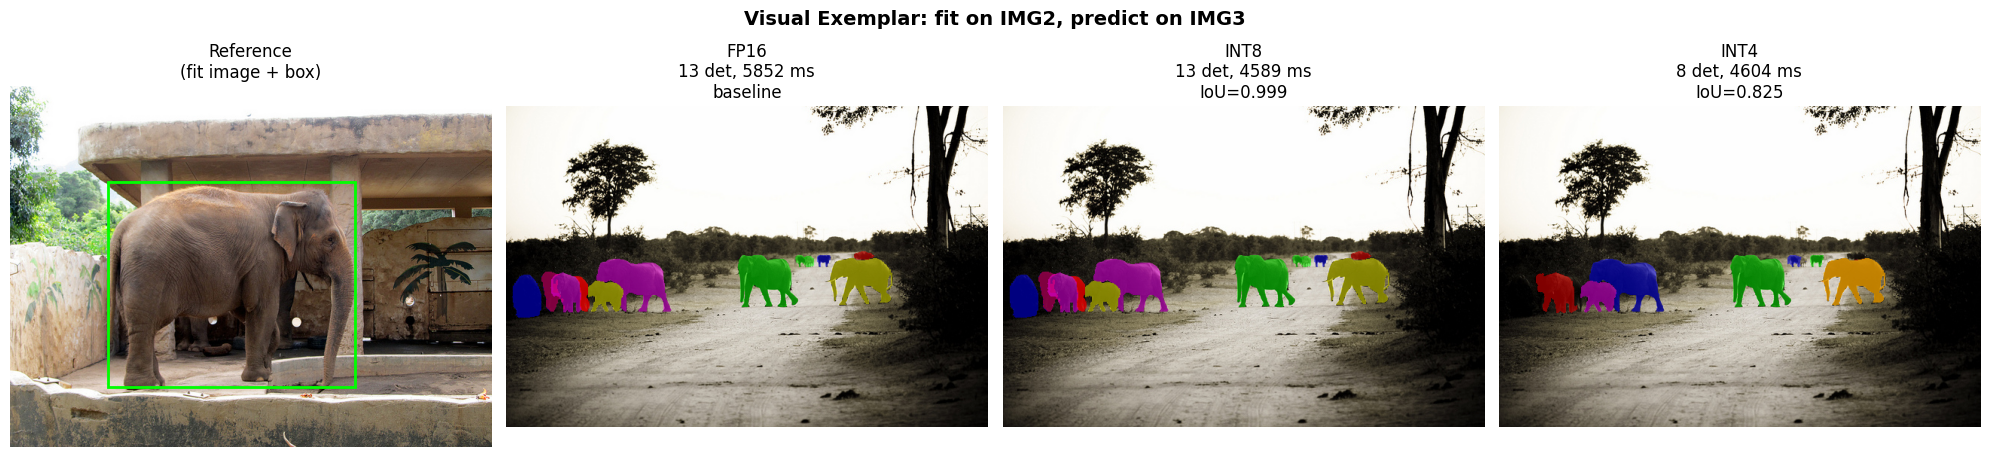

In [20]:
ref_sample = Sample(
    image_path=str(IMG2),
    bboxes=np.array([IMG2_BOX_COORDS]),
    categories=["elephant"],
    category_ids=[0],
)
ve_target = Sample(image_path=str(IMG3))

ve_results = {}
ve_latencies = {}
for name, variant in VARIANTS.items():
    print(f"Loading {name} in VISUAL_EXEMPLAR mode...")
    model_ve = SAM3OpenVINO(
        variant=variant,
        prompt_mode=Sam3PromptMode.VISUAL_EXEMPLAR,
        device=DEVICE,
    )
    model_ve.fit(ref_sample)
    pred = model_ve.predict(ve_target)
    latency = measure_latency(model_ve, ve_target, n=5)
    ve_results[name] = pred[0]
    ve_latencies[name] = latency
    print(f"  {name}: {len(pred[0]['pred_masks'])} detections, {latency:.1f} ms")
    del model_ve

# IoU vs FP16
baseline_masks = ve_results["FP16"]["pred_masks"]
print("\nMask IoU vs FP16 baseline (visual exemplar):")
ve_ious = {}
for name, pred in ve_results.items():
    if name == "FP16":
        ve_ious[name] = 1.0
        continue
    if len(baseline_masks) > 0 and len(pred["pred_masks"]) > 0:
        base_union = baseline_masks.sum(dim=0).clamp(max=1)
        pred_union = pred["pred_masks"].sum(dim=0).clamp(max=1)
        iou = compute_mask_iou(base_union, pred_union)
    else:
        iou = 0.0
    ve_ious[name] = iou
    print(f"  {name}: IoU = {iou:.4f}")

# Visualization
fig, axes = plt.subplots(1, len(VARIANTS) + 1, figsize=(5 * (len(VARIANTS) + 1), 5))
# Reference image
ref_img = cv2.imread(str(IMG2))
ref_img = cv2.cvtColor(ref_img, cv2.COLOR_BGR2RGB)
axes[0].imshow(ref_img)
axes[0].set_title("Reference\n(fit image + box)")
axes[0].axis("off")
# Add box overlay on reference
x1, y1, x2, y2 = IMG2_BOX_COORDS
import matplotlib.patches as patches
rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor="lime", facecolor="none")
axes[0].add_patch(rect)

for ax, (name, pred) in zip(axes[1:], ve_results.items()):
    vis = overlay_masks(IMG3, pred["pred_masks"])
    ax.imshow(vis)
    iou_str = f"IoU={ve_ious[name]:.3f}" if name != "FP16" else "baseline"
    ax.set_title(f"{name}\n{len(pred['pred_masks'])} det, {ve_latencies[name]:.0f} ms\n{iou_str}")
    ax.axis("off")
fig.suptitle("Visual Exemplar: fit on IMG2, predict on IMG3", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()